# Chapter 38 — Cell Division Detection and Lineage Construction

Chapter 37 created longer refined tracks. This lesson converts those tracks into a first **cell lineage graph**.

## Objectives

- Load Chapter 37 refined tracks
- Find plausible parent-to-daughter track pairs
- Combine daughter pairs into division candidates
- Score and select non-conflicting divisions
- Build lineage nodes and lineage edges
- Evaluate predicted divisions against GEFF ground truth
- Save reusable Chapter 38 outputs

## Required inputs

```text
chapter37_refined_track_nodes.csv
chapter37_refined_track_edges.csv
chapter37_refined_track_summary.csv
```

## Main outputs

```text
chapter38_division_candidates.csv
chapter38_selected_divisions.csv
chapter38_lineage_nodes.csv
chapter38_lineage_edges.csv
chapter38_lineage_summary.csv
```

In [1]:
!pip install -q zarr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 72.8 MB/s eta 0:00:00


In [2]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr

from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
from IPython.display import display


## 1. Configuration

In [3]:
@dataclass(frozen=True)
class DivisionConfig:
    sample_id: str = "44b6_12dfb391"

    z_scale: float = 1.625
    y_scale: float = 0.40625
    x_scale: float = 0.40625

    minimum_parent_length: int = 3
    minimum_daughter_length: int = 2

    maximum_division_gap: int = 3
    maximum_parent_to_daughter_distance: float = 12.0
    maximum_daughter_separation: float = 18.0

    minimum_division_score: float = 0.45
    node_match_radius: float = 6.0


CONFIG = DivisionConfig()
print(CONFIG)


DivisionConfig(sample_id='44b6_12dfb391', z_scale=1.625, y_scale=0.40625, x_scale=0.40625, minimum_parent_length=3, minimum_daughter_length=2, maximum_division_gap=3, maximum_parent_to_daughter_distance=12.0, maximum_daughter_separation=18.0, minimum_division_score=0.45, node_match_radius=6.0)


## 2. Load Chapter 37 outputs

Change only `DATA_DIR` when your Kaggle dataset folder has a different name.

In [4]:
DATA_DIR = Path("/kaggle/input/datasets/emailchrismathews/data37")

paths = {
    "nodes": DATA_DIR / "/kaggle/input/datasets/emailchrismathews/data37/chapter37_refined_track_nodes.csv",
    "edges": DATA_DIR / "/kaggle/input/datasets/emailchrismathews/chapter37-refined-track-edges/chapter37_refined_track_edges.csv",
    "summary": DATA_DIR / "/kaggle/input/datasets/emailchrismathews/chapter37-refined-track-edges/chapter37_refined_track_summary.csv",
}

for name, path in paths.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing {name}: {path}")
    print(f"{name}: {path}")

refined_track_nodes_df = pd.read_csv(paths["nodes"])
refined_track_edges_df = pd.read_csv(paths["edges"])
refined_track_summary_df = pd.read_csv(paths["summary"])

print()
print("nodes", len(refined_track_nodes_df))
print("edges", len(refined_track_edges_df))
print("tracks", refined_track_nodes_df["track_id"].nunique())

display(refined_track_nodes_df.head())
display(refined_track_summary_df.head())


nodes: /kaggle/input/datasets/emailchrismathews/data37/chapter37_refined_track_nodes.csv
edges: /kaggle/input/datasets/emailchrismathews/chapter37-refined-track-edges/chapter37_refined_track_edges.csv
summary: /kaggle/input/datasets/emailchrismathews/chapter37-refined-track-edges/chapter37_refined_track_summary.csv

nodes 4642
edges 3362
tracks 591


,track_id,detection_id,t,z,y,x,z_physical,y_physical,x_physical,rank_position,pred_dist,original_track_id
0,0,chapter34_t0_0,0,41.0,130.0,131.0,66.625,52.81250,53.21875,1,7.354238,0
1,0,chapter34_t1_66,1,40.0,127.0,127.0,65.000,51.59375,51.59375,67,17.145113,0
2,0,chapter34_t5_121,5,36.0,80.0,82.0,58.500,32.50000,33.31250,122,17.788210,0
3,0,chapter34_t6_108,6,35.0,78.0,72.0,56.875,31.68750,29.25000,109,17.851830,0
4,1,chapter34_t0_1,0,24.0,123.0,85.0,39.000,49.96875,34.53125,2,7.437489,1


,track_id,start_t,end_t,num_detections,duration,coverage_fraction,mean_rank,mean_pred_dist,path_length_physical,net_displacement_physical,path_efficiency
0,133,9,99,42,91,0.461538,82.380952,16.345565,343.713226,87.342804,0.254115
1,150,15,83,38,69,0.550725,60.315789,15.526533,283.397400,59.090874,0.208509
2,166,17,89,38,73,0.520548,46.263158,15.538851,114.195267,36.492466,0.319562
3,335,50,99,33,50,0.660000,61.515152,15.418617,155.334381,18.407206,0.118501
4,113,5,53,32,49,0.653061,61.156250,15.746547,160.438339,70.759842,0.441041


## 3. Add physical coordinates

In [5]:
def ensure_physical_coordinates(nodes, config=CONFIG):
    result = nodes.copy()

    if "z_physical" not in result:
        result["z_physical"] = result["z"].astype(float) * config.z_scale
    if "y_physical" not in result:
        result["y_physical"] = result["y"].astype(float) * config.y_scale
    if "x_physical" not in result:
        result["x_physical"] = result["x"].astype(float) * config.x_scale

    return result


refined_track_nodes_df = ensure_physical_coordinates(refined_track_nodes_df)

display(
    refined_track_nodes_df[
        ["track_id", "detection_id", "t", "z_physical", "y_physical", "x_physical"]
    ].head()
)


,track_id,detection_id,t,z_physical,y_physical,x_physical
0,0,chapter34_t0_0,0,66.625,52.81250,53.21875
1,0,chapter34_t1_66,1,65.000,51.59375,51.59375
2,0,chapter34_t5_121,5,58.500,32.50000,33.31250
3,0,chapter34_t6_108,6,56.875,31.68750,29.25000
4,1,chapter34_t0_1,0,39.000,49.96875,34.53125


## 4. Build track endpoint features

In [6]:
def endpoint_velocity(points, times, use_end):
    if len(points) < 2:
        return np.zeros(3, dtype=np.float32)

    if use_end:
        p0, p1 = points[-2], points[-1]
        t0, t1 = times[-2], times[-1]
    else:
        p0, p1 = points[0], points[1]
        t0, t1 = times[0], times[1]

    dt = max(int(t1 - t0), 1)
    return ((p1 - p0) / dt).astype(np.float32)


def build_track_endpoint_table(track_nodes):
    rows = []

    for track_id, group in track_nodes.groupby("track_id", sort=True):
        group = group.sort_values("t").reset_index(drop=True)

        points = group[
            ["z_physical", "y_physical", "x_physical"]
        ].to_numpy(dtype=np.float32)

        times = group["t"].to_numpy(dtype=np.int32)

        start_velocity = endpoint_velocity(points, times, use_end=False)
        end_velocity = endpoint_velocity(points, times, use_end=True)

        rows.append({
            "track_id": int(track_id),
            "start_t": int(times[0]),
            "end_t": int(times[-1]),
            "num_detections": len(group),

            "start_z": float(points[0, 0]),
            "start_y": float(points[0, 1]),
            "start_x": float(points[0, 2]),

            "end_z": float(points[-1, 0]),
            "end_y": float(points[-1, 1]),
            "end_x": float(points[-1, 2]),

            "start_vz": float(start_velocity[0]),
            "start_vy": float(start_velocity[1]),
            "start_vx": float(start_velocity[2]),

            "end_vz": float(end_velocity[0]),
            "end_vy": float(end_velocity[1]),
            "end_vx": float(end_velocity[2]),

            "mean_rank": float(group["rank_position"].mean()),
            "mean_pred_dist": float(group["pred_dist"].mean()),
        })

    return pd.DataFrame(rows)


track_endpoint_df = build_track_endpoint_table(refined_track_nodes_df)
display(track_endpoint_df.sort_values("num_detections", ascending=False).head(20))


,track_id,start_t,end_t,num_detections,start_z,start_y,start_x,end_z,end_y,end_x,start_vz,start_vy,start_vx,end_vz,end_vy,end_vx,mean_rank,mean_pred_dist
133,133,9,99,42,56.875,23.15625,71.90625,32.500,91.40625,23.15625,1.625000,-0.406250,-0.812500,4.875000,-1.218750,0.000000,82.380952,16.345565
150,150,15,83,38,76.375,60.12500,51.59375,56.875,85.71875,2.03125,-1.625000,5.890625,-3.250000,-1.625000,-0.812500,-0.406250,60.315789,15.526533
166,166,17,89,38,39.000,94.25000,29.65625,8.125,103.59375,12.59375,0.812500,0.000000,0.000000,-0.541667,0.677083,-0.270833,46.263158,15.538851
335,335,50,99,33,24.375,80.03125,7.71875,27.625,86.12500,24.78125,1.625000,0.406250,3.250000,0.000000,0.000000,0.406250,61.515152,15.418617
113,113,5,53,32,68.250,91.00000,42.65625,82.875,29.65625,74.75000,-0.812500,-2.234375,0.406250,3.250000,0.000000,2.437500,61.156250,15.746547
107,107,4,63,32,22.750,77.18750,24.37500,40.625,57.28125,8.93750,0.000000,-0.406250,-1.625000,3.250000,0.135417,-2.031250,79.843750,16.549199
17,17,0,63,31,29.250,101.56250,36.56250,26.000,97.50000,44.28125,3.250000,2.031250,0.000000,-3.250000,0.000000,1.218750,57.483871,15.859641
263,263,40,99,30,35.750,80.84375,56.06250,29.250,91.40625,1.62500,2.031250,-2.640625,1.523438,2.437500,0.203125,-1.421875,55.800000,15.636702
196,196,22,70,30,81.250,10.56250,57.28125,61.750,44.68750,67.03125,1.625000,-1.625000,0.000000,-0.541667,3.114583,-0.812500,51.766667,15.350907
5,5,0,56,29,65.000,81.65625,38.59375,45.500,101.96875,23.96875,-1.625000,3.250000,-4.062500,1.625000,4.875000,2.843750,54.379310,15.541005


## 5. Generate parent-to-daughter pair candidates

In [7]:
def generate_parent_daughter_pairs(endpoints, config=CONFIG):
    rows = []

    parents = endpoints[
        endpoints["num_detections"] >= config.minimum_parent_length
    ]

    daughters = endpoints[
        endpoints["num_detections"] >= config.minimum_daughter_length
    ]

    for parent in parents.itertuples(index=False):
        parent_end = np.array(
            [parent.end_z, parent.end_y, parent.end_x],
            dtype=np.float32,
        )

        parent_velocity = np.array(
            [parent.end_vz, parent.end_vy, parent.end_vx],
            dtype=np.float32,
        )

        for daughter in daughters.itertuples(index=False):
            if parent.track_id == daughter.track_id:
                continue

            gap = int(daughter.start_t - parent.end_t)

            if gap < 1 or gap > config.maximum_division_gap:
                continue

            daughter_start = np.array(
                [daughter.start_z, daughter.start_y, daughter.start_x],
                dtype=np.float32,
            )

            predicted_position = parent_end + parent_velocity * gap
            distance = float(np.linalg.norm(daughter_start - predicted_position))

            if distance > config.maximum_parent_to_daughter_distance * gap:
                continue

            rows.append({
                "parent_track_id": int(parent.track_id),
                "daughter_track_id": int(daughter.track_id),
                "parent_end_t": int(parent.end_t),
                "daughter_start_t": int(daughter.start_t),
                "frame_gap": gap,
                "distance": distance,

                "parent_num_detections": int(parent.num_detections),
                "daughter_num_detections": int(daughter.num_detections),

                "parent_mean_rank": float(parent.mean_rank),
                "daughter_mean_rank": float(daughter.mean_rank),

                "parent_mean_pred_dist": float(parent.mean_pred_dist),
                "daughter_mean_pred_dist": float(daughter.mean_pred_dist),

                "parent_end_z": float(parent.end_z),
                "parent_end_y": float(parent.end_y),
                "parent_end_x": float(parent.end_x),

                "daughter_start_z": float(daughter.start_z),
                "daughter_start_y": float(daughter.start_y),
                "daughter_start_x": float(daughter.start_x),
            })

    return pd.DataFrame(rows)


parent_daughter_pairs_df = generate_parent_daughter_pairs(
    track_endpoint_df,
    CONFIG,
)

print("parent-daughter pairs", len(parent_daughter_pairs_df))
display(parent_daughter_pairs_df.head(20))


parent-daughter pairs 272


,parent_track_id,daughter_track_id,parent_end_t,daughter_start_t,frame_gap,distance,parent_num_detections,daughter_num_detections,parent_mean_rank,daughter_mean_rank,parent_mean_pred_dist,daughter_mean_pred_dist,parent_end_z,parent_end_y,parent_end_x,daughter_start_z,daughter_start_y,daughter_start_x
0,5,352,56,57,1,11.058660,29,11,54.379310,28.545455,15.541005,14.801149,45.500,101.96875,23.96875,45.500,96.28125,23.96875
1,8,364,56,59,3,34.472557,16,2,52.312500,70.500000,15.097620,16.363314,68.250,28.84375,68.25000,69.875,56.87500,79.21875
2,8,371,56,59,3,31.773294,16,6,52.312500,84.500000,15.097620,16.622006,68.250,28.84375,68.25000,71.500,44.28125,48.34375
3,18,281,38,40,2,21.607153,11,7,35.363636,68.000000,14.523573,15.386958,37.375,57.28125,25.59375,40.625,79.62500,27.21875
4,18,285,38,40,2,18.737949,11,5,35.363636,67.600000,14.523573,15.856493,37.375,57.28125,25.59375,55.250,61.75000,13.81250
5,18,291,38,41,3,25.399040,11,4,35.363636,80.250000,14.523573,15.942641,37.375,57.28125,25.59375,52.000,70.28125,39.40625
6,22,312,44,47,3,32.624176,26,14,72.576923,66.642857,15.638879,15.870508,76.375,30.87500,47.53125,81.250,8.53125,62.96875
7,22,314,44,47,3,35.881329,26,2,72.576923,68.000000,15.638879,15.286445,76.375,30.87500,47.53125,74.750,5.28125,64.59375
8,23,85,3,6,3,33.013905,3,27,124.666667,80.037037,15.981761,16.340417,37.375,93.43750,21.12500,47.125,97.90625,51.59375
9,26,153,14,17,3,29.006363,10,3,65.800000,43.666667,15.898643,15.767481,45.500,42.25000,41.84375,65.000,32.50000,70.68750


## 6. Combine two daughters into each division candidate

In [8]:
def build_division_candidates(pair_candidates, config=CONFIG):
    rows = []

    if pair_candidates.empty:
        return pd.DataFrame()

    for parent_track_id, group in pair_candidates.groupby(
        "parent_track_id",
        sort=True,
    ):
        records = list(group.itertuples(index=False))

        for a, b in combinations(records, 2):
            if a.daughter_track_id == b.daughter_track_id:
                continue

            if abs(a.daughter_start_t - b.daughter_start_t) > 1:
                continue

            pos_a = np.array(
                [a.daughter_start_z, a.daughter_start_y, a.daughter_start_x],
                dtype=np.float32,
            )
            pos_b = np.array(
                [b.daughter_start_z, b.daughter_start_y, b.daughter_start_x],
                dtype=np.float32,
            )

            daughter_separation = float(np.linalg.norm(pos_a - pos_b))

            if daughter_separation > config.maximum_daughter_separation:
                continue

            distance_balance = min(a.distance, b.distance) / max(
                max(a.distance, b.distance),
                1e-6,
            )

            length_balance = min(
                a.daughter_num_detections,
                b.daughter_num_detections,
            ) / max(
                a.daughter_num_detections,
                b.daughter_num_detections,
            )

            rows.append({
                "parent_track_id": int(parent_track_id),
                "daughter_track_id_a": int(a.daughter_track_id),
                "daughter_track_id_b": int(b.daughter_track_id),

                "parent_end_t": int(a.parent_end_t),
                "daughter_start_t_a": int(a.daughter_start_t),
                "daughter_start_t_b": int(b.daughter_start_t),

                "frame_gap_a": int(a.frame_gap),
                "frame_gap_b": int(b.frame_gap),

                "distance_a": float(a.distance),
                "distance_b": float(b.distance),
                "mean_distance": float((a.distance + b.distance) / 2.0),
                "distance_balance": float(distance_balance),
                "daughter_separation": daughter_separation,
                "daughter_length_balance": float(length_balance),

                "parent_num_detections": int(a.parent_num_detections),
                "daughter_num_detections_a": int(a.daughter_num_detections),
                "daughter_num_detections_b": int(b.daughter_num_detections),

                "parent_mean_rank": float(a.parent_mean_rank),
                "daughter_mean_rank_a": float(a.daughter_mean_rank),
                "daughter_mean_rank_b": float(b.daughter_mean_rank),

                "parent_mean_pred_dist": float(a.parent_mean_pred_dist),
                "daughter_mean_pred_dist_a": float(a.daughter_mean_pred_dist),
                "daughter_mean_pred_dist_b": float(b.daughter_mean_pred_dist),
            })

    return pd.DataFrame(rows)


division_candidates_df = build_division_candidates(
    parent_daughter_pairs_df,
    CONFIG,
)

print("division candidates", len(division_candidates_df))
display(division_candidates_df.head(20))


division candidates 93


,parent_track_id,daughter_track_id_a,daughter_track_id_b,parent_end_t,daughter_start_t_a,daughter_start_t_b,frame_gap_a,frame_gap_b,distance_a,distance_b,...,daughter_length_balance,parent_num_detections,daughter_num_detections_a,daughter_num_detections_b,parent_mean_rank,daughter_mean_rank_a,daughter_mean_rank_b,parent_mean_pred_dist,daughter_mean_pred_dist_a,daughter_mean_pred_dist_b
0,22,312,314,44,47,47,3,3,32.624176,35.881329,...,0.142857,26,14,2,72.576923,66.642857,68.000000,15.638879,15.870508,15.286445
1,30,133,134,6,9,9,3,3,33.961384,30.052891,...,0.071429,5,42,3,86.000000,82.380952,34.333333,16.592465,16.345565,15.646203
2,31,130,135,7,9,10,2,3,22.284580,29.264103,...,0.500000,7,14,7,50.428571,58.071429,55.857143,15.166600,16.153696,15.244536
3,47,228,241,28,31,31,3,3,34.527069,30.273804,...,0.210526,13,19,4,47.846154,89.894737,121.000000,15.844786,16.468750,16.607940
4,47,228,245,28,31,31,3,3,34.527069,35.414307,...,0.578947,13,19,11,47.846154,89.894737,48.181818,15.844786,16.468750,15.321624
5,47,241,245,28,31,31,3,3,30.273804,35.414307,...,0.363636,13,4,11,47.846154,121.000000,48.181818,15.844786,16.607940,15.321624
6,63,277,295,39,42,42,3,3,28.922674,35.417511,...,1.000000,18,4,4,72.277778,11.000000,116.250000,16.628394,14.242868,16.839860
7,66,165,166,15,17,17,2,2,20.462261,19.672737,...,0.131579,3,5,38,34.333333,23.200000,46.263158,13.084436,14.317716,15.538851
8,69,181,185,17,20,20,3,3,25.694309,33.468811,...,1.000000,3,18,18,30.000000,61.555556,80.666667,15.075145,15.726143,16.393109
9,69,181,188,17,20,20,3,3,25.694309,26.837879,...,0.750000,3,18,24,30.000000,61.555556,77.791667,15.075145,15.726143,16.050463


## 7. Score division candidates

In [9]:
def minmax(values, reverse=False):
    values = values.astype(float)

    if values.max() == values.min():
        result = pd.Series(
            np.ones(len(values)),
            index=values.index,
            dtype=float,
        )
    else:
        result = (values - values.min()) / (values.max() - values.min())

    if reverse:
        result = 1.0 - result

    return result.clip(0.0, 1.0)


def score_division_candidates(candidates, config=CONFIG):
    if candidates.empty:
        return candidates.copy()

    scored = candidates.copy()

    max_distance = (
        config.maximum_parent_to_daughter_distance
        * config.maximum_division_gap
    )

    scored["distance_score"] = (
        1.0 - scored["mean_distance"] / max_distance
    ).clip(0.0, 1.0)

    ideal_separation = config.maximum_daughter_separation / 2.0

    scored["separation_score"] = (
        1.0
        - abs(scored["daughter_separation"] - ideal_separation)
        / max(ideal_separation, 1e-6)
    ).clip(0.0, 1.0)

    scored["balance_score"] = (
        0.5 * scored["distance_balance"]
        + 0.5 * scored["daughter_length_balance"]
    )

    daughter_length = (
        scored["daughter_num_detections_a"]
        + scored["daughter_num_detections_b"]
    ) / 2.0

    daughter_rank = (
        scored["daughter_mean_rank_a"]
        + scored["daughter_mean_rank_b"]
    ) / 2.0

    daughter_pred_dist = (
        scored["daughter_mean_pred_dist_a"]
        + scored["daughter_mean_pred_dist_b"]
    ) / 2.0

    scored["parent_quality_score"] = (
        0.5 * minmax(scored["parent_num_detections"])
        + 0.25 * minmax(scored["parent_mean_rank"], reverse=True)
        + 0.25 * minmax(scored["parent_mean_pred_dist"], reverse=True)
    )

    scored["daughter_quality_score"] = (
        0.5 * minmax(daughter_length)
        + 0.25 * minmax(daughter_rank, reverse=True)
        + 0.25 * minmax(daughter_pred_dist, reverse=True)
    )

    scored["division_score"] = (
        0.35 * scored["distance_score"]
        + 0.20 * scored["balance_score"]
        + 0.15 * scored["separation_score"]
        + 0.15 * scored["parent_quality_score"]
        + 0.15 * scored["daughter_quality_score"]
    )

    return scored.sort_values(
        "division_score",
        ascending=False,
    ).reset_index(drop=True)


division_candidates_df = score_division_candidates(
    division_candidates_df,
    CONFIG,
)

display(division_candidates_df.head(30))


,parent_track_id,daughter_track_id_a,daughter_track_id_b,parent_end_t,daughter_start_t_a,daughter_start_t_b,frame_gap_a,frame_gap_b,distance_a,distance_b,...,daughter_mean_rank_b,parent_mean_pred_dist,daughter_mean_pred_dist_a,daughter_mean_pred_dist_b,distance_score,separation_score,balance_score,parent_quality_score,daughter_quality_score,division_score
0,83,155,156,14,15,15,1,1,9.911194,8.797476,...,58.882353,14.544073,13.405217,15.525601,0.740157,0.292533,0.679109,0.401419,0.552195,0.581799
1,349,389,390,61,62,62,1,1,11.440104,9.272829,...,43.400000,15.386548,16.003807,15.685215,0.712320,0.725038,0.555277,0.333126,0.312078,0.565904
2,108,181,185,17,20,20,3,3,27.948702,25.654936,...,80.666667,15.214449,15.726143,16.393109,0.255505,0.839483,0.958965,0.415234,0.511296,0.546122
3,108,185,188,17,20,20,3,3,25.654936,29.880785,...,77.791667,15.214449,16.393109,16.050463,0.228671,0.960825,0.804288,0.415234,0.555268,0.530591
4,208,318,365,56,58,57,2,1,17.525345,11.261994,...,96.000000,16.674182,16.271588,15.681017,0.600176,0.990664,0.521306,0.247673,0.151152,0.522746
5,418,515,524,83,85,86,2,3,21.191301,27.255106,...,37.666667,15.177265,15.854596,14.359413,0.327133,0.988944,0.722092,0.373134,0.363118,0.517694
6,66,165,166,15,17,17,2,2,20.462261,19.672737,...,46.263158,13.084436,14.317716,15.538851,0.442569,0.446852,0.546497,0.452556,0.750104,0.511626
7,366,392,393,60,62,62,2,2,20.173903,18.959301,...,85.733333,14.515395,15.777567,16.178409,0.456483,0.312731,0.795984,0.404960,0.507676,0.502771
8,69,181,185,17,20,20,3,3,25.694309,33.468811,...,80.666667,15.075145,15.726143,16.393109,0.178290,0.839483,0.883855,0.330973,0.511296,0.491435
9,69,185,188,17,20,20,3,3,33.468811,26.837879,...,77.791667,15.075145,16.393109,16.050463,0.162407,0.960825,0.775939,0.330973,0.555268,0.489090


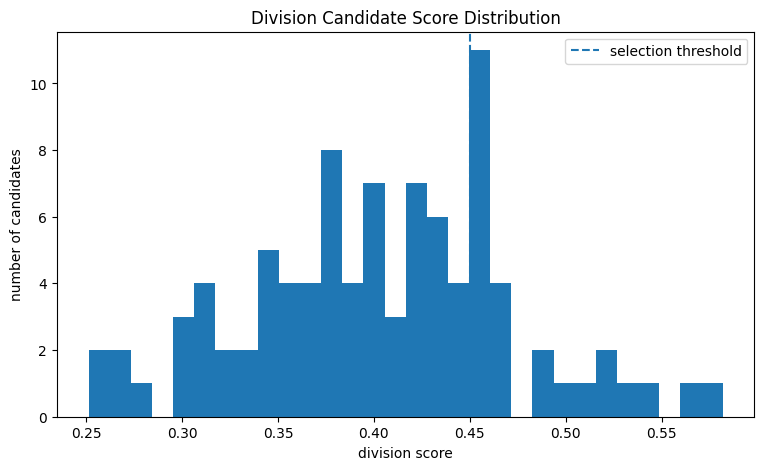

In [10]:
if not division_candidates_df.empty:
    plt.figure(figsize=(9, 5))
    plt.hist(division_candidates_df["division_score"], bins=30)
    plt.axvline(
        CONFIG.minimum_division_score,
        linestyle="--",
        label="selection threshold",
    )
    plt.title("Division Candidate Score Distribution")
    plt.xlabel("division score")
    plt.ylabel("number of candidates")
    plt.legend()
    plt.show()
else:
    print("No division candidates were generated.")


## 8. Select non-conflicting divisions

In [11]:
def select_divisions(scored_candidates, config=CONFIG):
    if scored_candidates.empty:
        return scored_candidates.copy()

    selected = []
    used_parents = set()
    used_daughters = set()

    for row in scored_candidates.itertuples(index=False):
        if row.division_score < config.minimum_division_score:
            continue

        parent = int(row.parent_track_id)
        daughter_a = int(row.daughter_track_id_a)
        daughter_b = int(row.daughter_track_id_b)

        if parent in used_parents:
            continue

        if daughter_a in used_daughters or daughter_b in used_daughters:
            continue

        if parent in {daughter_a, daughter_b}:
            continue

        selected.append(row._asdict())
        used_parents.add(parent)
        used_daughters.update([daughter_a, daughter_b])

    return pd.DataFrame(selected)


selected_divisions_df = select_divisions(
    division_candidates_df,
    CONFIG,
)

print("selected divisions", len(selected_divisions_df))
display(selected_divisions_df.head(30))


selected divisions 13


,parent_track_id,daughter_track_id_a,daughter_track_id_b,parent_end_t,daughter_start_t_a,daughter_start_t_b,frame_gap_a,frame_gap_b,distance_a,distance_b,...,daughter_mean_rank_b,parent_mean_pred_dist,daughter_mean_pred_dist_a,daughter_mean_pred_dist_b,distance_score,separation_score,balance_score,parent_quality_score,daughter_quality_score,division_score
0,83,155,156,14,15,15,1,1,9.911194,8.797476,...,58.882353,14.544073,13.405217,15.525601,0.740157,0.292533,0.679109,0.401419,0.552195,0.581799
1,349,389,390,61,62,62,1,1,11.440104,9.272829,...,43.400000,15.386548,16.003807,15.685215,0.712320,0.725038,0.555277,0.333126,0.312078,0.565904
2,108,181,185,17,20,20,3,3,27.948702,25.654936,...,80.666667,15.214449,15.726143,16.393109,0.255505,0.839483,0.958965,0.415234,0.511296,0.546122
3,208,318,365,56,58,57,2,1,17.525345,11.261994,...,96.000000,16.674182,16.271588,15.681017,0.600176,0.990664,0.521306,0.247673,0.151152,0.522746
4,418,515,524,83,85,86,2,3,21.191301,27.255106,...,37.666667,15.177265,15.854596,14.359413,0.327133,0.988944,0.722092,0.373134,0.363118,0.517694
5,66,165,166,15,17,17,2,2,20.462261,19.672737,...,46.263158,13.084436,14.317716,15.538851,0.442569,0.446852,0.546497,0.452556,0.750104,0.511626
6,366,392,393,60,62,62,2,2,20.173903,18.959301,...,85.733333,14.515395,15.777567,16.178409,0.456483,0.312731,0.795984,0.404960,0.507676,0.502771
7,329,370,399,61,63,64,2,3,23.948946,28.713463,...,81.111111,15.543535,15.843225,16.781264,0.268578,0.934684,0.805922,0.260100,0.234461,0.469573
8,405,509,511,82,83,84,1,2,9.422898,16.769812,...,83.333333,16.494798,15.017439,15.945459,0.636212,0.464614,0.530948,0.217602,0.223272,0.464687
9,96,183,184,17,20,20,3,3,24.506886,28.514475,...,91.875000,16.374598,15.768881,16.273058,0.263592,0.934931,0.763060,0.207857,0.312250,0.463125


## 9. Build lineage tables

In [12]:
def build_lineage_tables(track_summary, selected_divisions):
    lineage_nodes = track_summary.copy()
    lineage_nodes["has_parent"] = False
    lineage_nodes["num_daughters"] = 0
    lineage_nodes["is_dividing_parent"] = False

    edge_rows = []

    for row in selected_divisions.itertuples(index=False):
        for daughter in [
            int(row.daughter_track_id_a),
            int(row.daughter_track_id_b),
        ]:
            edge_rows.append({
                "parent_track_id": int(row.parent_track_id),
                "daughter_track_id": daughter,
                "division_time": int(row.parent_end_t),
                "division_score": float(row.division_score),
                "edge_type": "division",
            })

    lineage_edges = pd.DataFrame(edge_rows)

    if not lineage_edges.empty:
        parent_counts = lineage_edges.groupby("parent_track_id").size()
        daughter_ids = set(lineage_edges["daughter_track_id"])

        lineage_nodes["is_dividing_parent"] = lineage_nodes["track_id"].isin(
            parent_counts.index
        )

        lineage_nodes["num_daughters"] = (
            lineage_nodes["track_id"]
            .map(parent_counts)
            .fillna(0)
            .astype(int)
        )

        lineage_nodes["has_parent"] = lineage_nodes["track_id"].isin(
            daughter_ids
        )

    lineage_summary = pd.DataFrame({
        "metric": [
            "num_tracks",
            "num_selected_divisions",
            "num_division_edges",
            "num_dividing_parents",
            "num_daughter_tracks",
            "num_root_tracks",
        ],
        "value": [
            lineage_nodes["track_id"].nunique(),
            len(selected_divisions),
            len(lineage_edges),
            lineage_nodes["is_dividing_parent"].sum(),
            lineage_nodes["has_parent"].sum(),
            (~lineage_nodes["has_parent"]).sum(),
        ],
    })

    return lineage_nodes, lineage_edges, lineage_summary


lineage_nodes_df, lineage_edges_df, lineage_summary_df = build_lineage_tables(
    refined_track_summary_df,
    selected_divisions_df,
)

display(lineage_nodes_df.head())
display(lineage_edges_df.head())
display(lineage_summary_df)


,track_id,start_t,end_t,num_detections,duration,coverage_fraction,mean_rank,mean_pred_dist,path_length_physical,net_displacement_physical,path_efficiency,has_parent,num_daughters,is_dividing_parent
0,133,9,99,42,91,0.461538,82.380952,16.345565,343.713226,87.342804,0.254115,False,0,False
1,150,15,83,38,69,0.550725,60.315789,15.526533,283.397400,59.090874,0.208509,False,0,False
2,166,17,89,38,73,0.520548,46.263158,15.538851,114.195267,36.492466,0.319562,True,0,False
3,335,50,99,33,50,0.660000,61.515152,15.418617,155.334381,18.407206,0.118501,False,0,False
4,113,5,53,32,49,0.653061,61.156250,15.746547,160.438339,70.759842,0.441041,False,0,False


,parent_track_id,daughter_track_id,division_time,division_score,edge_type
0,83,155,14,0.581799,division
1,83,156,14,0.581799,division
2,349,389,61,0.565904,division
3,349,390,61,0.565904,division
4,108,181,17,0.546122,division


,metric,value
0,num_tracks,591
1,num_selected_divisions,13
2,num_division_edges,26
3,num_dividing_parents,13
4,num_daughter_tracks,26
5,num_root_tracks,565


## 10. Visualize selected divisions

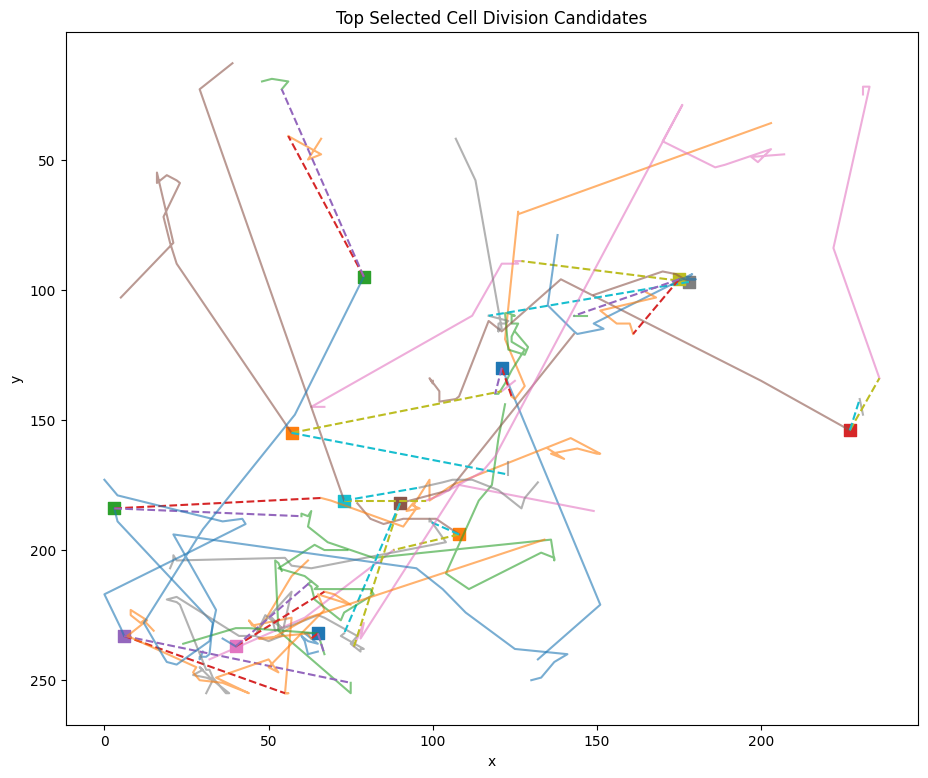

In [13]:
def plot_selected_divisions(
    track_nodes,
    selected_divisions,
    maximum_divisions=20,
):
    if selected_divisions.empty:
        print("No selected divisions to plot.")
        return

    plt.figure(figsize=(11, 9))

    for row in selected_divisions.head(maximum_divisions).itertuples(index=False):
        parent = track_nodes[
            track_nodes["track_id"] == row.parent_track_id
        ].sort_values("t")

        daughter_a = track_nodes[
            track_nodes["track_id"] == row.daughter_track_id_a
        ].sort_values("t")

        daughter_b = track_nodes[
            track_nodes["track_id"] == row.daughter_track_id_b
        ].sort_values("t")

        if parent.empty or daughter_a.empty or daughter_b.empty:
            continue

        parent_end = parent.iloc[-1]
        daughter_a_start = daughter_a.iloc[0]
        daughter_b_start = daughter_b.iloc[0]

        plt.plot(parent["x"], parent["y"], alpha=0.6)
        plt.plot(daughter_a["x"], daughter_a["y"], alpha=0.6)
        plt.plot(daughter_b["x"], daughter_b["y"], alpha=0.6)

        plt.plot(
            [parent_end["x"], daughter_a_start["x"]],
            [parent_end["y"], daughter_a_start["y"]],
            linestyle="--",
        )

        plt.plot(
            [parent_end["x"], daughter_b_start["x"]],
            [parent_end["y"], daughter_b_start["y"]],
            linestyle="--",
        )

        plt.scatter(
            [parent_end["x"]],
            [parent_end["y"]],
            marker="s",
            s=70,
        )

    plt.gca().invert_yaxis()
    plt.title("Top Selected Cell Division Candidates")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()


plot_selected_divisions(
    refined_track_nodes_df,
    selected_divisions_df,
)


## 11. Load GEFF ground truth and extract true divisions

In [14]:
def load_gt(sample_id):
    root = Path(
        "/kaggle/input/competitions/"
        "biohub-cell-tracking-during-development/train"
    )

    geff_path = root / f"{sample_id}.geff"

    if not geff_path.exists():
        print("Ground truth not found. Evaluation will be skipped.")
        return None, None

    geff = zarr.open(geff_path, mode="r")

    gt_nodes = pd.DataFrame({
        "gt_node_id": geff["nodes/ids"][:],
        "t": geff["nodes/props/t/values"][:],
        "z": geff["nodes/props/z/values"][:],
        "y": geff["nodes/props/y/values"][:],
        "x": geff["nodes/props/x/values"][:],
    })

    edge_ids = np.asarray(geff["edges/ids"][:])

    gt_edges = pd.DataFrame({
        "gt_source": edge_ids[:, 0],
        "gt_target": edge_ids[:, 1],
    })

    return gt_nodes, gt_edges


def extract_gt_divisions(gt_edges):
    rows = []

    for parent, group in gt_edges.groupby("gt_source", sort=True):
        daughters = sorted(group["gt_target"].unique())

        if len(daughters) < 2:
            continue

        for daughter_a, daughter_b in combinations(daughters, 2):
            rows.append({
                "gt_parent": parent,
                "gt_daughter_a": daughter_a,
                "gt_daughter_b": daughter_b,
            })

    return pd.DataFrame(rows)


gt_nodes_df, gt_edges_df = load_gt(CONFIG.sample_id)

if gt_nodes_df is not None:
    gt_divisions_df = extract_gt_divisions(gt_edges_df)

    print("GT nodes", len(gt_nodes_df))
    print("GT edges", len(gt_edges_df))
    print("GT divisions", len(gt_divisions_df))

    display(gt_divisions_df.head())
else:
    gt_divisions_df = pd.DataFrame()


GT nodes 788
GT edges 773
GT divisions 1


,gt_parent,gt_daughter_a,gt_daughter_b
0,172000000050,173000000050,173000000051


## 12. Match refined detections to GT nodes

In [15]:
def match_nodes_to_gt(track_nodes, gt_nodes, radius):
    rows = []

    for t in sorted(track_nodes["t"].unique()):
        pred_t = track_nodes[track_nodes["t"] == t].reset_index(drop=True)
        gt_t = gt_nodes[gt_nodes["t"] == t].reset_index(drop=True)

        if pred_t.empty or gt_t.empty:
            continue

        distances = cdist(
            pred_t[["z", "y", "x"]].to_numpy(dtype=np.float32),
            gt_t[["z", "y", "x"]].to_numpy(dtype=np.float32),
        )

        safe = np.where(distances <= radius, distances, 1e9)
        pred_indices, gt_indices = linear_sum_assignment(safe)

        for pred_index, gt_index in zip(pred_indices, gt_indices):
            distance = float(distances[pred_index, gt_index])

            if distance > radius:
                continue

            rows.append({
                "detection_id": pred_t.iloc[pred_index]["detection_id"],
                "track_id": int(pred_t.iloc[pred_index]["track_id"]),
                "t": int(t),
                "gt_node_id": gt_t.iloc[gt_index]["gt_node_id"],
                "match_distance": distance,
            })

    return pd.DataFrame(rows)


if gt_nodes_df is not None:
    track_node_matches_df = match_nodes_to_gt(
        refined_track_nodes_df,
        gt_nodes_df,
        CONFIG.node_match_radius,
    )

    print("matched nodes", len(track_node_matches_df))
    display(track_node_matches_df.head())
else:
    track_node_matches_df = pd.DataFrame()


matched nodes 294


,detection_id,track_id,t,gt_node_id,match_distance
0,chapter34_t0_0,0,0,1.060000e+11,3.316625
1,chapter34_t0_1,1,0,1.060000e+11,1.000000
2,chapter34_t0_3,3,0,1.060000e+11,2.449490
3,chapter34_t0_5,5,0,1.060000e+11,2.449490
4,chapter34_t0_12,11,0,1.060000e+11,1.000000


## 13. Map tracks to dominant GT identities

In [16]:
def build_track_to_gt_mapping(node_matches):
    if node_matches.empty:
        return pd.DataFrame()

    counts = (
        node_matches
        .groupby(["track_id", "gt_node_id"])
        .size()
        .reset_index(name="match_count")
    )

    totals = (
        counts.groupby("track_id")["match_count"]
        .sum()
        .rename("total_matches")
    )

    best = (
        counts
        .sort_values(
            ["track_id", "match_count"],
            ascending=[True, False],
        )
        .drop_duplicates("track_id")
        .merge(totals, on="track_id", how="left")
    )

    best["track_match_purity"] = (
        best["match_count"] / best["total_matches"].clip(lower=1)
    )

    return best


track_to_gt_df = build_track_to_gt_mapping(
    track_node_matches_df
)

display(track_to_gt_df.head(20))


,track_id,gt_node_id,match_count,total_matches,track_match_purity
0,0,1.060000e+11,1,2,0.500000
1,1,1.060000e+11,1,2,0.500000
2,3,1.060000e+11,1,6,0.166667
3,4,1.180000e+11,1,5,0.200000
4,5,1.060000e+11,1,2,0.500000
5,6,1.100000e+11,1,4,0.250000
6,8,1.160000e+11,1,2,0.500000
7,11,1.060000e+11,1,1,1.000000
8,12,1.080000e+11,1,1,1.000000
9,13,1.410000e+11,1,3,0.333333


## 14. Evaluate selected divisions

In [17]:
def evaluate_divisions(
    selected_divisions,
    track_to_gt,
    gt_divisions,
):
    if selected_divisions.empty or track_to_gt.empty:
        return pd.DataFrame(), pd.DataFrame()

    mapping = dict(
        zip(
            track_to_gt["track_id"],
            track_to_gt["gt_node_id"],
        )
    )

    true_divisions = {
        (
            row.gt_parent,
            frozenset([row.gt_daughter_a, row.gt_daughter_b]),
        )
        for row in gt_divisions.itertuples(index=False)
    }

    rows = []

    for row in selected_divisions.itertuples(index=False):
        gt_parent = mapping.get(int(row.parent_track_id))
        gt_a = mapping.get(int(row.daughter_track_id_a))
        gt_b = mapping.get(int(row.daughter_track_id_b))

        all_matched = (
            gt_parent is not None
            and gt_a is not None
            and gt_b is not None
        )

        correct = False

        if all_matched:
            correct = (
                gt_parent,
                frozenset([gt_a, gt_b]),
            ) in true_divisions

        rows.append({
            "parent_track_id": int(row.parent_track_id),
            "daughter_track_id_a": int(row.daughter_track_id_a),
            "daughter_track_id_b": int(row.daughter_track_id_b),
            "division_score": float(row.division_score),
            "gt_parent": gt_parent,
            "gt_daughter_a": gt_a,
            "gt_daughter_b": gt_b,
            "all_tracks_matched": all_matched,
            "correct_division": correct,
        })

    evaluation = pd.DataFrame(rows)

    matched = int(evaluation["all_tracks_matched"].sum())
    correct = int(evaluation["correct_division"].sum())

    summary = pd.DataFrame({
        "metric": [
            "selected_divisions",
            "all_tracks_matched",
            "correct_divisions",
            "precision_all",
            "precision_matched_only",
        ],
        "value": [
            len(evaluation),
            matched,
            correct,
            correct / max(len(evaluation), 1),
            correct / max(matched, 1),
        ],
    })

    return evaluation, summary


division_evaluation_df, division_evaluation_summary_df = evaluate_divisions(
    selected_divisions_df,
    track_to_gt_df,
    gt_divisions_df,
)

display(division_evaluation_df.head(20))
display(division_evaluation_summary_df)


,parent_track_id,daughter_track_id_a,daughter_track_id_b,division_score,gt_parent,gt_daughter_a,gt_daughter_b,all_tracks_matched,correct_division
0,83,155,156,0.581799,NaN,NaN,NaN,False,False
1,349,389,390,0.565904,NaN,NaN,NaN,False,False
2,108,181,185,0.546122,NaN,1.260000e+11,1.260000e+11,False,False
3,208,318,365,0.522746,NaN,NaN,NaN,False,False
4,418,515,524,0.517694,NaN,NaN,NaN,False,False
5,66,165,166,0.511626,NaN,NaN,1.840000e+11,False,False
6,366,392,393,0.502771,1.650000e+11,1.860000e+11,NaN,False,False
7,329,370,399,0.469573,NaN,NaN,NaN,False,False
8,405,509,511,0.464687,NaN,NaN,NaN,False,False
9,96,183,184,0.463125,NaN,1.260000e+11,NaN,False,False


,metric,value
0,selected_divisions,13.0
1,all_tracks_matched,0.0
2,correct_divisions,0.0
3,precision_all,0.0
4,precision_matched_only,0.0


## 15. Validate the lineage graph

In [18]:
def validate_lineage(lineage_edges):
    if lineage_edges.empty:
        return pd.DataFrame([{
            "check": "lineage_graph",
            "passed": True,
            "details": "No divisions selected.",
        }])

    parent_counts = lineage_edges.groupby("parent_track_id").size()
    daughter_counts = lineage_edges.groupby("daughter_track_id").size()

    validation = pd.DataFrame([
        {
            "check": "two_daughters_per_parent",
            "passed": bool((parent_counts == 2).all()),
            "details": f"{len(parent_counts)} parents checked",
        },
        {
            "check": "one_parent_per_daughter",
            "passed": bool((daughter_counts <= 1).all()),
            "details": f"{len(daughter_counts)} daughters checked",
        },
        {
            "check": "no_self_divisions",
            "passed": bool(
                (
                    lineage_edges["parent_track_id"]
                    != lineage_edges["daughter_track_id"]
                ).all()
            ),
            "details": "Parent and daughter track IDs differ",
        },
    ])

    if not validation["passed"].all():
        raise ValueError("Lineage validation failed.")

    return validation


lineage_validation_df = validate_lineage(lineage_edges_df)

print("Lineage validation passed.")
display(lineage_validation_df)


Lineage validation passed.


,check,passed,details
0,two_daughters_per_parent,True,13 parents checked
1,one_parent_per_daughter,True,26 daughters checked
2,no_self_divisions,True,Parent and daughter track IDs differ


## 16. Save Chapter 38 outputs

In [19]:
OUTPUT_DIR = Path("/kaggle/working")

output_paths = {
    "parent_daughter_pairs": OUTPUT_DIR / "chapter38_parent_daughter_pairs.csv",
    "division_candidates": OUTPUT_DIR / "chapter38_division_candidates.csv",
    "selected_divisions": OUTPUT_DIR / "chapter38_selected_divisions.csv",
    "lineage_nodes": OUTPUT_DIR / "chapter38_lineage_nodes.csv",
    "lineage_edges": OUTPUT_DIR / "chapter38_lineage_edges.csv",
    "lineage_summary": OUTPUT_DIR / "chapter38_lineage_summary.csv",
    "gt_node_matches": OUTPUT_DIR / "chapter38_gt_node_matches.csv",
    "track_to_gt": OUTPUT_DIR / "chapter38_track_to_gt_mapping.csv",
    "division_evaluation": OUTPUT_DIR / "chapter38_division_evaluation.csv",
    "division_evaluation_summary": OUTPUT_DIR / "chapter38_division_evaluation_summary.csv",
    "lineage_validation": OUTPUT_DIR / "chapter38_lineage_validation.csv",
}

parent_daughter_pairs_df.to_csv(
    output_paths["parent_daughter_pairs"],
    index=False,
)

division_candidates_df.to_csv(
    output_paths["division_candidates"],
    index=False,
)

selected_divisions_df.to_csv(
    output_paths["selected_divisions"],
    index=False,
)

lineage_nodes_df.to_csv(
    output_paths["lineage_nodes"],
    index=False,
)

lineage_edges_df.to_csv(
    output_paths["lineage_edges"],
    index=False,
)

lineage_summary_df.to_csv(
    output_paths["lineage_summary"],
    index=False,
)

lineage_validation_df.to_csv(
    output_paths["lineage_validation"],
    index=False,
)

if not track_node_matches_df.empty:
    track_node_matches_df.to_csv(
        output_paths["gt_node_matches"],
        index=False,
    )

if not track_to_gt_df.empty:
    track_to_gt_df.to_csv(
        output_paths["track_to_gt"],
        index=False,
    )

if not division_evaluation_df.empty:
    division_evaluation_df.to_csv(
        output_paths["division_evaluation"],
        index=False,
    )

if not division_evaluation_summary_df.empty:
    division_evaluation_summary_df.to_csv(
        output_paths["division_evaluation_summary"],
        index=False,
    )

for name, path in output_paths.items():
    if path.exists():
        print(f"Saved {name}: {path}")


Saved parent_daughter_pairs: /kaggle/working/chapter38_parent_daughter_pairs.csv
Saved division_candidates: /kaggle/working/chapter38_division_candidates.csv
Saved selected_divisions: /kaggle/working/chapter38_selected_divisions.csv
Saved lineage_nodes: /kaggle/working/chapter38_lineage_nodes.csv
Saved lineage_edges: /kaggle/working/chapter38_lineage_edges.csv
Saved lineage_summary: /kaggle/working/chapter38_lineage_summary.csv
Saved gt_node_matches: /kaggle/working/chapter38_gt_node_matches.csv
Saved track_to_gt: /kaggle/working/chapter38_track_to_gt_mapping.csv
Saved division_evaluation: /kaggle/working/chapter38_division_evaluation.csv
Saved division_evaluation_summary: /kaggle/working/chapter38_division_evaluation_summary.csv
Saved lineage_validation: /kaggle/working/chapter38_lineage_validation.csv


# Chapter 38 complete

## Pipeline now completed

```text
Raw Volume
    ↓
Cell Detection
    ↓
Detection Ranking
    ↓
Tracking
    ↓
Track Filtering
    ↓
Gap Closing
    ↓
Division Candidate Generation
    ↓
Division Selection
    ↓
Lineage Graph
```

## Required files for the next lesson

```text
chapter38_selected_divisions.csv
chapter38_lineage_nodes.csv
chapter38_lineage_edges.csv
```

## Strongly recommended diagnostic files

```text
chapter38_division_candidates.csv
chapter38_division_evaluation.csv
chapter38_division_evaluation_summary.csv
chapter38_lineage_validation.csv
```

Use **Save Version → Save & Run All (Commit)** to preserve everything in `/kaggle/working`.

A low division score or low precision does not automatically mean the notebook failed. Division quality depends on the quality of the detections, refined tracks, track endpoints, and GT matching.
